### This notebook contains a detailed description of the dataset along with relevant statistical summaries.

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
features = pd.read_csv('../features.csv')
targets = pd.read_csv('../targets.csv')
data = features.merge(targets[['study_id','case_ISUP']], on='study_id')
X = data.drop(['study_id','patient_id','case_ISUP'], axis=1) # predictors
y = data['case_ISUP'] # target variable

In [3]:
# Count of study_ids per ISUP grade 
counts = data.groupby('case_ISUP')['study_id'].nunique()

print(counts)


case_ISUP
0    589
1    157
2    154
3     69
4     27
5     35
Name: study_id, dtype: int64


In [4]:
print(len(data['study_id']))
print(len(data['patient_id']))

1031
1031


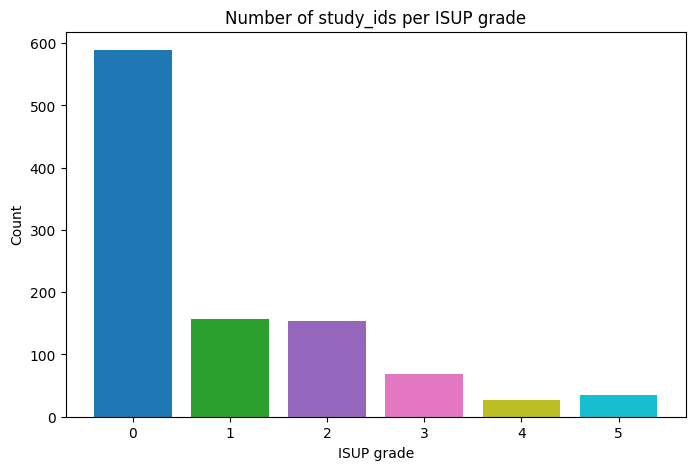

In [5]:
# Example: counts is a pandas Series with ISUP grades as index
# counts.index → ISUP grades
# counts.values → counts per grade


colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=colors)

plt.title("Number of study_ids per ISUP grade")
plt.xlabel("ISUP grade")
plt.ylabel("Count")

plt.show()


### In the following cell, we balance the dataset by:
- Identifying, for each class from 1 to 5, the k = 1 nearest neighbor from class 0.
- Applying SMOTE (Synthetic Minority Over‑Sampling Technique) to augment the minority classes.

In [6]:
df = X.copy() 
df["case_ISUP"] = y

idx_class0 = df.index[df["case_ISUP"] == 0]

# Storage for selected class-0 samples 
selected_class0 = []

# For each class 1–5, find nearest class-0 sample

for cls in range(1, 6): 
    print(f"Processing class {cls}") 
    idx_cls = df.index[df["case_ISUP"] == cls] 
    
    # Fit KNN on class 0 samples 
    knn = NearestNeighbors(n_neighbors=1) 
    knn.fit(df.loc[idx_class0, X.columns]) 
    
    # For each sample in class cls, find nearest class-0 sample 
    distances, indices = knn.kneighbors(df.loc[idx_cls, X.columns]) 
    # Convert neighbor indices to original dataframe indices 
    nearest_idx0 = idx_class0[indices.flatten()] 
    # Add to list 
    selected_class0.extend(nearest_idx0)

# keep only unique samples in class 0
selected_class0 = list(set(selected_class0)) 
print(f"\nOriginal class 0 count: {len(idx_class0)}") 
print(f"New class 0 count: {len(selected_class0)}")

# new reduced dataset
df_new = pd.concat([ df[df["case_ISUP"] != 0], # keep all minority classes 
                    df.loc[selected_class0] # keep only selected class-0 samples ])
])

print("\nFinal class counts:")
print(df_new["case_ISUP"].value_counts().sort_index())



# SMOTE only for classes 3, 4, 5

X_smote = df_new.drop(columns=["case_ISUP"])
y_smote = df_new["case_ISUP"]

sampling_strategy = {
    3: 150,
    4: 150,
    5: 150
}

sm = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=3,
    random_state=42
)

X_resampled, y_resampled = sm.fit_resample(X_smote, y_smote)

df_resampled = pd.concat([
    pd.DataFrame(X_resampled, columns=X_smote.columns),
    pd.Series(y_resampled, name="case_ISUP")
], axis=1)

print("\nFinal class counts AFTER SMOTE:")
print(df_resampled["case_ISUP"].value_counts().sort_index())


Processing class 1
Processing class 2
Processing class 3
Processing class 4
Processing class 5

Original class 0 count: 589
New class 0 count: 262

Final class counts:
case_ISUP
0    262
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

Final class counts AFTER SMOTE:
case_ISUP
0    262
1    157
2    154
3    150
4    150
5    150
Name: count, dtype: int64


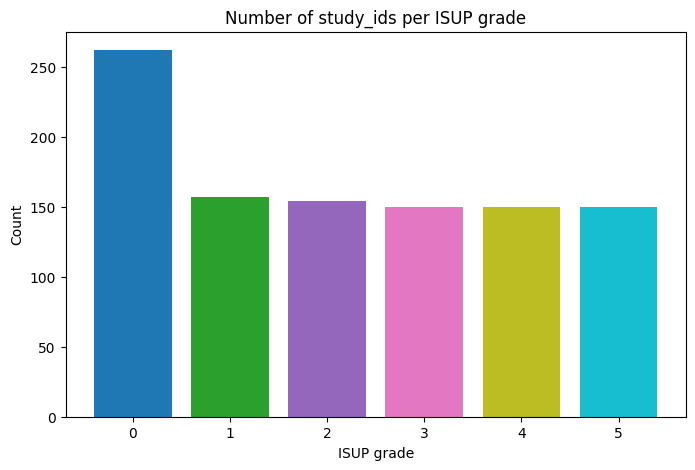

In [7]:
# Count the occurrences of each ISUP class
counts = df_resampled["case_ISUP"].value_counts().sort_index()

colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color=colors)

plt.title("Number of study_ids per ISUP grade")
plt.xlabel("ISUP grade")
plt.ylabel("Count")

plt.show()


In [8]:
# Correlation of predictors with ISUP grade
y_resampled = y_resampled.astype(int)
corrs = X_resampled.corrwith(y_resampled, method='spearman').sort_values(key=abs, ascending=False)

print(corrs.head(20))



original_firstorder_Minimum                           0.206413
original_shape_Sphericity                            -0.183850
original_shape_SurfaceVolumeRatio                     0.166361
original_gldm_LargeDependenceHighGrayLevelEmphasis    0.155700
original_gldm_DependenceEntropy                       0.137015
original_ngtdm_Strength                               0.136132
original_shape_LeastAxisLength                       -0.127305
original_ngtdm_Coarseness                             0.125283
original_glrlm_LongRunHighGrayLevelEmphasis           0.121773
original_gldm_SmallDependenceLowGrayLevelEmphasis    -0.118655
original_glszm_SmallAreaLowGrayLevelEmphasis         -0.115526
original_glcm_Imc2                                    0.115274
original_shape_MeshVolume                            -0.113116
original_shape_VoxelVolume                           -0.113049
original_shape_MinorAxisLength                       -0.111295
original_shape_MajorAxisLength                       -0

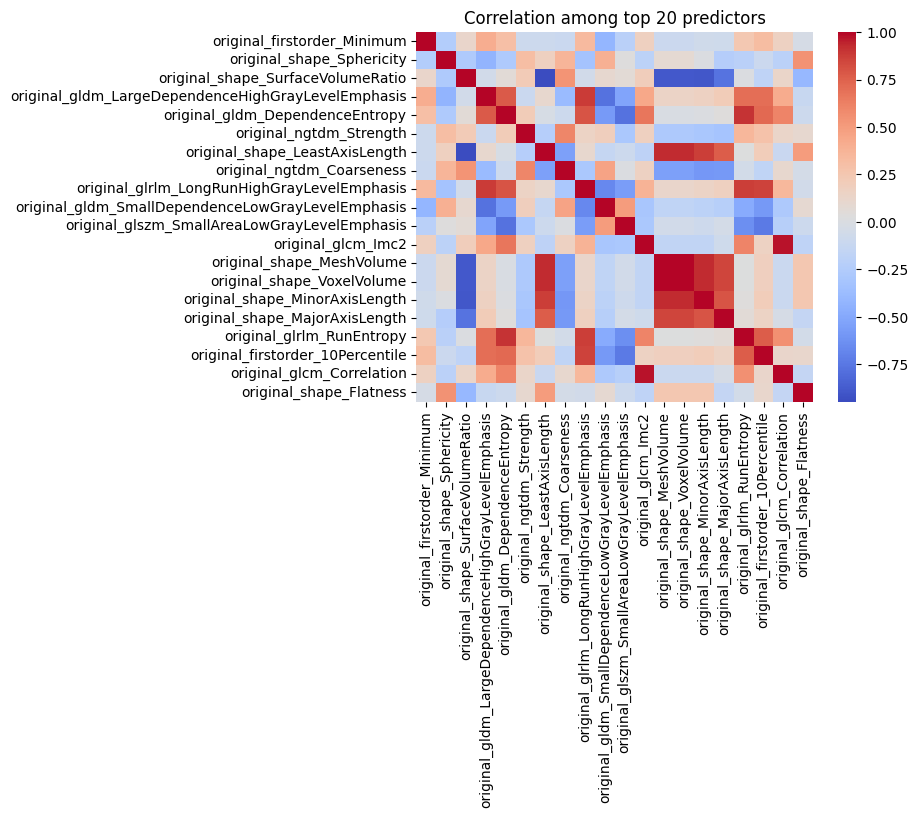

In [9]:
# Heatmap of top 20 correlated predictors
top_predictors = corrs.head(20).index
sns.heatmap(pd.DataFrame(X_resampled, columns=X_smote.columns)[top_predictors].corr(),
            cmap="coolwarm")
plt.title("Correlation among top 20 predictors")
plt.show()

In [10]:
# Statistics
predictor_stats = (
    data.groupby('case_ISUP')[X.columns]
        .agg([
            'mean',
            'median',
            'std',
            'min',
            'max',
            ('q25', lambda x: x.quantile(0.25)),
            ('q75', lambda x: x.quantile(0.75))
        ])
)

print(predictor_stats)

          original_shape_Elongation                                          \
                               mean    median       std       min       max   
case_ISUP                                                                     
0                          0.881161  0.897260  0.076314  0.586025  0.996473   
1                          0.855626  0.874988  0.086619  0.643241  0.992448   
2                          0.852903  0.863867  0.086276  0.399072  0.973635   
3                          0.866995  0.881706  0.075164  0.700211  0.981705   
4                          0.850365  0.837429  0.070938  0.702276  0.978886   
5                          0.881120  0.887666  0.068189  0.663479  0.992628   

                              original_shape_Flatness                      \
                q25       q75                    mean    median       std   
case_ISUP                                                                   
0          0.836036  0.939819                0.734196  0.